In [23]:
import numpy as np
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X = X / 255.0
y = y.astype(int)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

In [24]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        # Gradients on parameters
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        # Gradients on values
        self.dinputs = np.dot(dvalues, self.weights.T)

In [25]:
class Activation_ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)

    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0

In [26]:
#Softmax Activation
class Activation_Softmax:
    # Forward pass
    def forward(self, inputs):
        # Get unnormalized probabilities
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))

        # Normalize them for each sample
        probablities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        self.output = probablities

    # Backward pass
    def backward(self, dvalues):
        # Create uninitialized array
        self.dinputs = np.empty_like(dvalues)

        # Enumerate outputs and gradients
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)):
            single_output = single_output.reshape(-1,1)
            # Calculation of Jacobian matrix of the output 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T)

            # Calculate sample-wise gradient
            # add it to the array of sample gradients
            self.dinputs[index] = np.dot(jacobian_matrix, single_dvalues)

In [27]:
class Loss:
    def calculate(self, output, y):
        # calculate sample loss
        sample_loss = self.forward(output, y)
        # calculate mean loss
        data_loss = np.mean(sample_loss)
        return data_loss

In [28]:
class Loss_CategoricalCrossentrophy(Loss):

    # Forward pass
    def forward(self, y_pred, y_true):
        # number of sample in a batch
        sample = len(y_pred)

        # Clip data to prevent 0
        # Clip both sides to not drag mean towards any value
        y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)

        # probablities for target values
        # only if categorical labels
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(sample),
                y_true
            ]

        # Mask values (only for one hot encoded labels)
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped * y_true,
                axis=1
            )

        #Losses
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods
    
    # Backward pass
    def backward(self, dvalues, y_true):
        # number of Samples
        samples = len(dvalues)
        # number of labels in every sample
        labels = len(dvalues[0])
        # If labels are sparse, turning them into one-hot vector
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
        # Calculate gradient
        self.dinputs = -y_true / dvalues
        # Normalize gradients
        self.dinputs = self.dinputs / samples

In [29]:
class Activation_Softmax_Loss_CategoricalCrossentropy():
    # Creates activation and loss function objects
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss =  Loss_CategoricalCrossentrophy()
    # Forward pass
    def forward(self, inputs, y_true):
        # Output layer's activation function
        self.activation.forward(inputs)
        # Set the output
        self.output = self.activation.output
        # Calculate and return loss value
        return self.loss.calculate(self.output, y_true)
   
    # Backward pass
    def backward(self, dvalues, y_true):
        # Number of samples
        samples = len(dvalues)
        # If labels are one-hot encoded,
        # turn them into discrete values
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
        # Copy so we can safely modify
        self.dinputs = dvalues.copy()
        # Calculate gradient
        self.dinputs[range(samples), y_true] -= 1
        # Normalize gradient
        self.dinputs = self.dinputs / samples

In [30]:
class Optimizer_SGD:
    # Initializing optimizer
    # learning rate
    def __init__(self, learning_rate=1):
        self.learning_rate = learning_rate

    def update_params(self, layer):
        layer.weights += -self.learning_rate * layer.dweights
        layer.biases += -self.learning_rate * layer.dbiases

In [31]:
# Model
optimizer = Optimizer_SGD(learning_rate=0.5)
dense1 = Layer_Dense(784, 64)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(64, 10)
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

y_batch = y_train
if len(y_batch.shape) == 2:
    y_batch = np.argmax(y_batch, axis=1)

for i in range(100):
    # Forward pass
    dense1.forward(X_train)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)

    loss = loss_activation.forward(dense2.output, y_batch)
    predictions = np.argmax(loss_activation.output, axis=1)
    accuracy = np.mean(predictions == y_batch)

    print('acc:', accuracy)
    print('loss:', loss)
    print('epoch:', i)

    # Backward pass
    loss_activation.backward(loss_activation.output, y_batch)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # Update weights and biases
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)

    if accuracy >= 0.9:
        break

acc: 0.09856666666666666
loss: 2.302048825328241
epoch: 0
acc: 0.2432
loss: 2.299289358143843
epoch: 1
acc: 0.3305
loss: 2.296092023781892
epoch: 2
acc: 0.35795
loss: 2.291859582118761
epoch: 3
acc: 0.38403333333333334
loss: 2.285966504180181
epoch: 4
acc: 0.39936666666666665
loss: 2.2775767085460723
epoch: 5
acc: 0.4038333333333333
loss: 2.2655137882799563
epoch: 6
acc: 0.39975
loss: 2.2481748154129546
epoch: 7
acc: 0.39248333333333335
loss: 2.2234908514040024
epoch: 8
acc: 0.39131666666666665
loss: 2.189071483349126
epoch: 9
acc: 0.40313333333333334
loss: 2.1424907479771402
epoch: 10
acc: 0.43016666666666664
loss: 2.0816551488318478
epoch: 11
acc: 0.47191666666666665
loss: 2.0050279655148233
epoch: 12
acc: 0.5188666666666667
loss: 1.9117662764187668
epoch: 13
acc: 0.5571333333333334
loss: 1.802709104052424
epoch: 14
acc: 0.58725
loss: 1.681945808321393
epoch: 15
acc: 0.6168166666666667
loss: 1.5567909235576944
epoch: 16
acc: 0.6519
loss: 1.4353367596283202
epoch: 17
acc: 0.6881
loss:

test loss 0.333 test acc 0.904


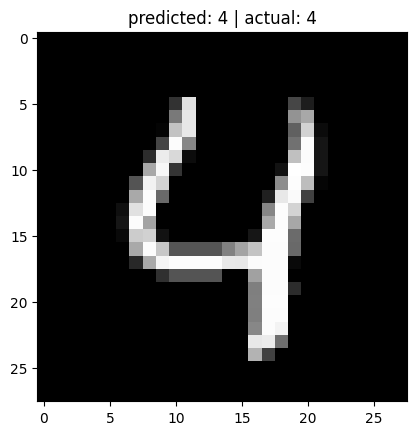

In [ ]:
dense1.forward(X_test)
activation1.forward(dense1.output)
dense2.forward(activation1.output)

# Keep label format consistent for loss/accuracy.
y_test_eval = y_test
if len(y_test_eval.shape) == 2:
    y_test_eval = np.argmax(y_test_eval, axis=1)

loss_test = loss_activation.forward(dense2.output, y_test_eval)
predictions_test = np.argmax(loss_activation.output, axis=1)
accuracy = np.mean(predictions_test == y_test_eval)

print(f'test loss {loss_test:.3f} test acc {accuracy:.3f}')

import matplotlib.pyplot as plt
# just for future preferences : use index[8]
idx = 8
pred = predictions_test[idx]

plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
plt.title(f'predicted: {pred} | actual: {int(y_test_eval[idx])}')
plt.show()